In [1]:
import xarray as xr
import rioxarray
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.ndimage import median_filter, minimum_filter, maximum_filter, uniform_filter
import lightgbm as lgb 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from tqdm import tqdm
import joblib
from pathlib import Path

In [2]:
year = 2021
RAW_XY_FOLDERPATH = Path(f'../data/silver/Xy-{year}')

# Load data

In [3]:
raw_Xy = pd.read_parquet(RAW_XY_FOLDERPATH / "Xy.parquet")
metadata_df = pd.read_parquet(RAW_XY_FOLDERPATH / "metadata_df.parquet")

raw_Xy.head(1)

,red,green,blue,rededge,B06,B07,nir,B8A,swir11,swir22,...,gndvi_11x11_min,gndvi_11x11_max,gndvi_11x11_var,ndwi_11x11_median,ndwi_11x11_min,ndwi_11x11_max,ndwi_11x11_var,y,region,scl
0,0.145098,0.105882,0.07451,0.188235,0.203922,0.215686,0.215686,0.227451,0.309804,0.254902,...,0.00112,0.001609,0.000002,0.00679,0.006232,0.007676,0.000012,False,Upper East,NOT_VEGETATED


# Build Xy

In [4]:
def get_base_and_scl_and_obs_cnt_and_cloud_conf_and_advanced_features(X):
    features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
    features += ['scl', 'region']
    features += ['tci', 'ndvi', 'evi', 'evi2', 'ndre_b5', 'ndre_b6', 'ndre_b7', 'gndvi', 'ndwi']
    features += ['valid_observations']
    features += ['cloud_confidence']
    features += [e for e in X.columns if any(k in e for k in ['3x3', '5x5', '11x11'])]
    return X[features + ['y']]

Xy = get_base_and_scl_and_obs_cnt_and_cloud_conf_and_advanced_features(raw_Xy)
Xy.head(1)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,...,ndre_b7_11x11_var,gndvi_11x11_median,gndvi_11x11_min,gndvi_11x11_max,gndvi_11x11_var,ndwi_11x11_median,ndwi_11x11_min,ndwi_11x11_max,ndwi_11x11_var,y
0,0.07451,0.105882,0.145098,0.188235,0.203922,0.215686,0.215686,0.227451,0.309804,0.254902,...,1.662564e-07,0.001408,0.00112,0.001609,0.000002,0.00679,0.006232,0.007676,0.000012,False


# Prep hyperparam optimization

In [13]:
import numpy as np
import optuna
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score, precision_score, recall_score

def optuna_objective_factory(X, y, groups, n_splits: int = 100):
    # Safely determine max possible splits based on unique groups
    unique_groups = len(np.unique(groups))
    actual_splits = min(n_splits, unique_groups)
    
    if actual_splits < n_splits:
        print(f"Warning: Requested {n_splits} splits, but only found {unique_groups} unique groups. Adjusting n_splits to {actual_splits}.")

    def objective(trial):
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 2, 15),
            'num_leaves': trial.suggest_int('num_leaves', 10, 256),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
            'n_jobs': -1,
            'verbose': -1,
            'random_state': 42
        }
        
        gkf = GroupKFold(n_splits=actual_splits)
        
        # Initialize lists to store metrics and raw arrays
        true_f1s, true_precisions, true_recalls = [], [], []
        false_f1s, false_precisions, false_recalls = [], [], []
        all_yhat_vals, all_y_vals = [], []
        
        for train_idx, val_idx in gkf.split(X, y, groups):
            # Safe slicing regardless of whether X/y are pandas DataFrames/Series or numpy arrays
            X_train = X.iloc[train_idx]
            X_val = X.iloc[val_idx]
            y_train = y.iloc[train_idx]
            y_val = y.iloc[val_idx] 
            
            # Fit/predict
            model = lgb.LGBMClassifier(**param)
            model.fit(X_train, y_train)
            yhat_val = model.predict(X_val)
            
            # Calculate and append metrics
            true_f1s.append(f1_score(y_val, yhat_val, zero_division=0))
            true_precisions.append(precision_score(y_val, yhat_val, zero_division=0))
            true_recalls.append(recall_score(y_val, yhat_val, zero_division=0))

            false_f1s.append(f1_score(y_val, yhat_val, zero_division=0, pos_label=0))
            false_precisions.append(precision_score(y_val, yhat_val, zero_division=0, pos_label=0))
            false_recalls.append(recall_score(y_val, yhat_val, zero_division=0, pos_label=0))
            
            all_yhat_vals.append(yhat_val.tolist())
            all_y_vals.append(y_val.tolist())

        # Store tracked data as user attributes in the trial
        trial.set_user_attr('true_f1s', true_f1s)
        trial.set_user_attr('true_precisions', true_precisions)
        trial.set_user_attr('true_recalls', true_recalls)
        trial.set_user_attr('false_f1s', false_f1s)
        trial.set_user_attr('false_precisions', false_precisions)
        trial.set_user_attr('false_recalls', false_recalls)
        trial.set_user_attr('yhat_vals', all_yhat_vals)
        trial.set_user_attr('y_vals', all_y_vals)
        
        return np.median(true_f1s)

    return objective

# Train:test split

In [14]:
def compute_a(y):
    return y.sum() / len(y)

def compute_ahat(yhat, y_vals, yhat_vals):
    area_proportion_1 = yhat.sum() / len(yhat)
    area_proportion_0 = 1 - area_proportion_1
    
    # Figure out precision/false-omission-rate as the weighted-mean
    cms = [confusion_matrix(y_val, yhat_val, labels=[True, False]) for y_val, yhat_val in zip(y_vals, yhat_vals)] # (tp, fn), (fp, tn)
    tps = [e[0][0] for e in cms]
    fns = [e[0][1] for e in cms]
    tns = [e[1][1] for e in cms]
    fps = [e[1][0] for e in cms]

    # Figure out weighted-averaged TN, ...
    n_vals = np.array([len(e) for e in y_vals])
    tp = np.mean(tps)
    fn = np.mean(fns)
    fp = np.mean(fps)
    tn = np.mean(tns)

    # Compute validation set's metrics
    false_omission_rate = fn / (fn + tn)
    precision = tp / (tp + fp)

    # Compute adjusted unbiased area proportion
    ahat = (area_proportion_1 * precision) + (area_proportion_0 * false_omission_rate)

    # Compute Confidence Interval (Olofsson Variance)
    n_cocoa = tp + fp
    n_non_cocoa = fn + tn

    # Variance contribution from both strata
    var_cocoa = (area_proportion_1 ** 2) * (precision * (1 - precision)) / (n_cocoa - 1)
    var_non_cocoa = (area_proportion_0 ** 2) * (false_omission_rate * (1 - false_omission_rate)) / (n_non_cocoa - 1)
    
    # Standard Error
    se = np.sqrt(var_cocoa + var_non_cocoa)
    
    # Margin of Error for 95% Confidence Interval (Z-score = 1.96)
    margin_of_error = 1.96 * se
    
    ci_lower = max(0.0, ahat - margin_of_error) # Clamp at 0%
    ci_upper = min(1.0, ahat + margin_of_error) # Clamp at 100%

    return ahat, (ci_lower, ci_upper)

In [15]:
def train_test_split(Xy, metadata_df, region: str, test_size=0.2):
    """Split a train/test set, where all test samples are located within a region."""
    region_mask = Xy.region.apply(lambda x: x.lower()) == region

    if not region_mask.sum():
        raise ValueError(f'Region {region} not found.')

    # Discard not-in-region data
    Xy = Xy[region_mask]
    metadata_df = metadata_df[region_mask]
    print(f"Discarding out-of-region points: Kept {region_mask.sum()}/{len(region_mask)} ({region_mask.sum()/len(region_mask) * 100:.2f}%)")
    Xy = Xy.drop(columns=['region'])
    
    # Figure out which folds are for train/val and which for test
    region_fold_idxs = metadata_df.fold_idx[region_mask].unique()
    n_test_folds = int(np.floor(test_size * len(region_fold_idxs)))
    test_fold_idxs = np.random.choice(region_fold_idxs, size=n_test_folds, replace=False)
    test_mask = metadata_df.fold_idx.isin(test_fold_idxs)
    print(f"{len(test_fold_idxs)}/{len(region_fold_idxs)} regions for testing ({test_mask.sum()} points)")
    
    return Xy[~test_mask], metadata_df[~test_mask], Xy[test_mask], metadata_df[test_mask]

Xy_train, train_metadata_df, Xy_test, test_metadata_df = train_test_split(Xy, metadata_df, 'upper east', 0.2)
Xy_train.head(1)

Discarding out-of-region points: Kept 35926/944808 (3.80%)
200/1000 regions for testing (7212 points)


,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,...,ndre_b7_11x11_var,gndvi_11x11_median,gndvi_11x11_min,gndvi_11x11_max,gndvi_11x11_var,ndwi_11x11_median,ndwi_11x11_min,ndwi_11x11_max,ndwi_11x11_var,y
0,0.07451,0.105882,0.145098,0.188235,0.203922,0.215686,0.215686,0.227451,0.309804,0.254902,...,1.662564e-07,0.001408,0.00112,0.001609,0.000002,0.00679,0.006232,0.007676,0.000012,False


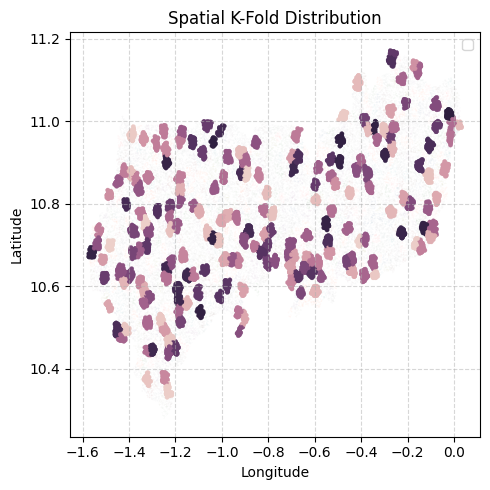

In [16]:
# Plot the folds
plt.figure(figsize=(5, 5))
sns.scatterplot(data=train_metadata_df, x='lon', y='lat', hue='fold_idx', palette='tab20', s=1, alpha=0.02, edgecolor=None)
sns.scatterplot(data=test_metadata_df, x='lon', y='lat', hue='fold_idx', color='r', s=10, alpha=1, edgecolor=None)

plt.title('Spatial K-Fold Distribution')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend([])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# Train

In [17]:
def train_test_lgbm(X_train, y_train, X_test, y_test, groups, n_splits=2, n_trials=3):
    print("Starting Optuna hyperparameter optimization...")
    study = optuna.create_study(direction="maximize") 
    study.optimize(optuna_objective_factory(X_train, y_train, groups, n_splits), n_trials=n_trials, show_progress_bar=True)
    
    # Build final model
    clf = lgb.LGBMClassifier(**study.best_params)
    clf.fit(X_train, y_train)
    
    yhat_train = clf.predict(X_train)
    yhat_test = clf.predict(X_test)

    # Validation-inferred correction
    yhat_vals = [np.array(e) for e in study.best_trial.user_attrs['yhat_vals']]
    y_vals = [np.array(e) for e in study.best_trial.user_attrs['y_vals']]
    ahat, (ci_lower, ci_upper) = compute_ahat(yhat_test, y_vals, yhat_vals)
    a = compute_a(y_test)
    print(f"Test region's estimated CAP: {ahat*100:.2f}% ({100 * ahat / a - 100:.2f}% off ETHZ's estimate)")
    print(f"95% Confidence Interval: [{ci_lower*100:.2f}%, {ci_upper*100:.2f}%]")
    
    print("\n--- OPTIMIZED MODEL EVALUATION ---")
    print("TRAIN")
    print(f"- F1: {f1_score(y_train, yhat_train, zero_division=0):.4f}")
    print(f"- Precision: {precision_score(y_train, yhat_train, zero_division=0):.4f}")
    print(f"- Recall: {recall_score(y_train, yhat_train, zero_division=0):.4f}")
    
    print("\nTEST")
    print(f"- F1: {f1_score(y_test, yhat_test, zero_division=0):.4f}")
    print(f"- Precision: {precision_score(y_test, yhat_test, zero_division=0):.4f}")
    print(f"- Recall: {recall_score(y_test, yhat_test, zero_division=0):.4f}")

    return clf, study.best_trial.user_attrs

In [18]:
def train_region(Xy, metadata_df, region, test_size=0.2, n_splits=2, n_trials=1):
    
    # Get train:test
    Xy_train, train_metadata_df, Xy_test, test_metadata_df = train_test_split(Xy, metadata_df, region.lower(), test_size)    
    X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
    X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

    # Train
    clf, user_attrs = train_test_lgbm(X_train, y_train, X_test, y_test, train_metadata_df.fold_idx, n_splits=n_splits, n_trials=n_trials);
    
    # Dump
    payload = {
        'X_train': X_train,
        'y_train': y_train,
        'metadata_df_train':  train_metadata_df,
        'X_test': X_test,
        'y_test': y_test,
        'metadata_df_test':  test_metadata_df,
        'clf': clf,
        "user_attrs": user_attrs,
    }
    
    joblib.dump(payload, f'trained-{region.lower()}-2021.joblib')

In [19]:
train_region(Xy, metadata_df, 'ashanti', 0.5, n_splits=20, n_trials=5)

[I 2026-06-29 09:31:02,861] A new study created in memory with name: no-name-da285184-af56-4992-91ba-2853f586dd58


Discarding out-of-region points: Kept 99065/944808 (10.49%)
500/1000 regions for testing (49422 points)
Starting Optuna hyperparameter optimization...


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-06-29 09:32:37,318] Trial 0 finished with value: 0.8041904790305643 and parameters: {'n_estimators': 496, 'learning_rate': 0.06650492682054389, 'max_depth': 6, 'num_leaves': 82, 'subsample': 0.5651331325829718, 'colsample_bytree': 0.6239172393544423, 'min_child_samples': 65}. Best is trial 0 with value: 0.8041904790305643.
[I 2026-06-29 09:33:49,003] Trial 1 finished with value: 0.7927708471485411 and parameters: {'n_estimators': 107, 'learning_rate': 0.04224090147804644, 'max_depth': 14, 'num_leaves': 185, 'subsample': 0.8421094510063862, 'colsample_bytree': 0.6233718326345377, 'min_child_samples': 81}. Best is trial 0 with value: 0.8041904790305643.
[I 2026-06-29 09:34:58,860] Trial 2 finished with value: 0.7798238968033697 and parameters: {'n_estimators': 348, 'learning_rate': 0.025514217219908188, 'max_depth': 4, 'num_leaves': 128, 'subsample': 0.93550172504081, 'colsample_bytree': 0.9451586226612176, 'min_child_samples': 89}. Best is trial 0 with value: 0.8041904790305643.

In [20]:
train_region(Xy, metadata_df, 'western north', 0.5, n_splits=20, n_trials=5)

[I 2026-06-29 09:37:33,857] A new study created in memory with name: no-name-c254afdb-7671-42ec-9d8a-867fbcc0278e


Discarding out-of-region points: Kept 33339/944808 (3.53%)
500/1000 regions for testing (16681 points)
Starting Optuna hyperparameter optimization...


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-06-29 09:40:38,010] Trial 0 finished with value: 0.8397888712706936 and parameters: {'n_estimators': 417, 'learning_rate': 0.010630871956864312, 'max_depth': 14, 'num_leaves': 151, 'subsample': 0.9073737088523071, 'colsample_bytree': 0.575843729522096, 'min_child_samples': 23}. Best is trial 0 with value: 0.8397888712706936.
[I 2026-06-29 09:40:48,995] Trial 1 finished with value: 0.8011980353174138 and parameters: {'n_estimators': 202, 'learning_rate': 0.037550863792194855, 'max_depth': 2, 'num_leaves': 221, 'subsample': 0.8128424318321363, 'colsample_bytree': 0.9464811125796074, 'min_child_samples': 46}. Best is trial 0 with value: 0.8397888712706936.
[I 2026-06-29 09:42:21,715] Trial 2 finished with value: 0.8403186866248189 and parameters: {'n_estimators': 426, 'learning_rate': 0.019192466604787704, 'max_depth': 13, 'num_leaves': 50, 'subsample': 0.7556632863589705, 'colsample_bytree': 0.8501743330298187, 'min_child_samples': 29}. Best is trial 2 with value: 0.8403186866248

In [21]:
train_region(Xy, metadata_df, 'western', 0.5, n_splits=20, n_trials=5)

[I 2026-06-29 09:43:42,863] A new study created in memory with name: no-name-5cc351b7-aaae-4a40-993e-ce131327795b


Discarding out-of-region points: Kept 38855/944808 (4.11%)
500/1000 regions for testing (19760 points)
Starting Optuna hyperparameter optimization...


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-06-29 09:44:32,169] Trial 0 finished with value: 0.8117002507196582 and parameters: {'n_estimators': 473, 'learning_rate': 0.013655161073607133, 'max_depth': 5, 'num_leaves': 17, 'subsample': 0.7560618432468369, 'colsample_bytree': 0.98026762358166, 'min_child_samples': 73}. Best is trial 0 with value: 0.8117002507196582.
[I 2026-06-29 09:44:55,869] Trial 1 finished with value: 0.815945700103612 and parameters: {'n_estimators': 418, 'learning_rate': 0.07219933405622136, 'max_depth': 3, 'num_leaves': 19, 'subsample': 0.6548315064360319, 'colsample_bytree': 0.8738299958551814, 'min_child_samples': 81}. Best is trial 1 with value: 0.815945700103612.
[I 2026-06-29 09:46:24,019] Trial 2 finished with value: 0.8235169624759943 and parameters: {'n_estimators': 462, 'learning_rate': 0.0785457433545323, 'max_depth': 14, 'num_leaves': 49, 'subsample': 0.65836582719686, 'colsample_bytree': 0.6535581314684165, 'min_child_samples': 25}. Best is trial 2 with value: 0.8235169624759943.
[I 202

In [22]:
train_region(Xy, metadata_df, 'ahafo', 0.5, n_splits=20, n_trials=5)

[I 2026-06-29 09:50:51,998] A new study created in memory with name: no-name-0a02da35-96de-4ea6-9397-0fc397dd8d74


Discarding out-of-region points: Kept 20436/944808 (2.16%)
500/1000 regions for testing (10062 points)
Starting Optuna hyperparameter optimization...


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-06-29 09:52:33,166] Trial 0 finished with value: 0.8481696943087647 and parameters: {'n_estimators': 356, 'learning_rate': 0.10086362147432432, 'max_depth': 13, 'num_leaves': 218, 'subsample': 0.7190380532809983, 'colsample_bytree': 0.645018340764824, 'min_child_samples': 56}. Best is trial 0 with value: 0.8481696943087647.
[I 2026-06-29 09:53:59,949] Trial 1 finished with value: 0.8396308630831959 and parameters: {'n_estimators': 462, 'learning_rate': 0.03411886130240768, 'max_depth': 9, 'num_leaves': 115, 'subsample': 0.5547279024099274, 'colsample_bytree': 0.6763550050674387, 'min_child_samples': 55}. Best is trial 0 with value: 0.8481696943087647.
[I 2026-06-29 09:55:42,771] Trial 2 finished with value: 0.8418560606060606 and parameters: {'n_estimators': 388, 'learning_rate': 0.03208978322682962, 'max_depth': 14, 'num_leaves': 165, 'subsample': 0.526058496911292, 'colsample_bytree': 0.9836612304916521, 'min_child_samples': 79}. Best is trial 0 with value: 0.8481696943087647

In [23]:
train_region(Xy, metadata_df, 'central', 0.5, n_splits=20, n_trials=5)

[I 2026-06-29 09:57:08,755] A new study created in memory with name: no-name-b486e1c8-8b13-477a-8ffa-a67911b8c468


Discarding out-of-region points: Kept 33440/944808 (3.54%)
500/1000 regions for testing (16724 points)
Starting Optuna hyperparameter optimization...


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-06-29 09:57:31,598] Trial 0 finished with value: 0.7515492682840273 and parameters: {'n_estimators': 157, 'learning_rate': 0.023209450401933056, 'max_depth': 13, 'num_leaves': 17, 'subsample': 0.8444030188079995, 'colsample_bytree': 0.9677528493665687, 'min_child_samples': 81}. Best is trial 0 with value: 0.7515492682840273.
[I 2026-06-29 09:58:02,119] Trial 1 finished with value: 0.755635858169617 and parameters: {'n_estimators': 86, 'learning_rate': 0.021141215002900154, 'max_depth': 15, 'num_leaves': 77, 'subsample': 0.5388237174111412, 'colsample_bytree': 0.9303004771241876, 'min_child_samples': 67}. Best is trial 1 with value: 0.755635858169617.
[I 2026-06-29 09:58:45,404] Trial 2 finished with value: 0.7759741752733761 and parameters: {'n_estimators': 121, 'learning_rate': 0.17348980177966047, 'max_depth': 11, 'num_leaves': 125, 'subsample': 0.8040657535453859, 'colsample_bytree': 0.500616094350355, 'min_child_samples': 19}. Best is trial 2 with value: 0.7759741752733761.

In [24]:
train_region(Xy, metadata_df, 'eastern', 0.5, n_splits=20, n_trials=5)

[I 2026-06-29 10:01:20,434] A new study created in memory with name: no-name-de7030bd-5dc1-41a4-a051-50aa06a30df9


Discarding out-of-region points: Kept 70356/944808 (7.45%)
500/1000 regions for testing (35077 points)
Starting Optuna hyperparameter optimization...


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-06-29 10:01:56,651] Trial 0 finished with value: 0.6744928169287516 and parameters: {'n_estimators': 85, 'learning_rate': 0.05994126915683698, 'max_depth': 8, 'num_leaves': 209, 'subsample': 0.8906962457107603, 'colsample_bytree': 0.6093892702077981, 'min_child_samples': 22}. Best is trial 0 with value: 0.6744928169287516.
[I 2026-06-29 10:02:35,517] Trial 1 finished with value: 0.7068227491961415 and parameters: {'n_estimators': 458, 'learning_rate': 0.11450043607910933, 'max_depth': 3, 'num_leaves': 208, 'subsample': 0.5447078157715959, 'colsample_bytree': 0.5262373114558545, 'min_child_samples': 74}. Best is trial 1 with value: 0.7068227491961415.
[I 2026-06-29 10:03:38,805] Trial 2 finished with value: 0.7004821600771456 and parameters: {'n_estimators': 248, 'learning_rate': 0.11166989116979709, 'max_depth': 13, 'num_leaves': 43, 'subsample': 0.697403465057433, 'colsample_bytree': 0.7219913071439834, 'min_child_samples': 53}. Best is trial 1 with value: 0.7068227491961415.


# Use TCA
https://en.wikipedia.org/wiki/Tasseled_cap_transformation

# Use clustering min ?